In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0.2,
)

In [11]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str
    evaluation: str

In [5]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [6]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [24]:
def evaluate_blog(state: BlogState) -> BlogState:
    content = state['content']

    prompt =f'Evaluate the following blog content and provide a score out of 10 along with a brief feedback \n {content}'

    state['evaluation'] = model.invoke(prompt).content
    return state

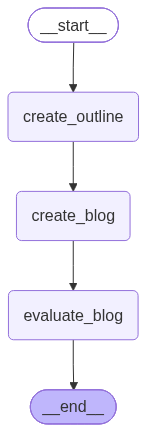

In [25]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluate_blog', evaluate_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)

workflow = graph.compile()
graph.compile()

In [26]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

c:\Users\kumar\OneDrive\Desktop\Resume\Langraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\kumar\OneDrive\Desktop\Resume\Langraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\kumar\OneDrive\Desktop\Resume\Langraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'title': 'Rise of AI in India', 'outline': [{'type': 'text', 'text': 'Here is a detailed, SEO-optimized blog outline on the topic **"The Rise of AI in India: From Silicon Valley to the Silicon subcontinent."**\n\n---\n\n# Blog Title Options:\n1. *The Rise of AI in India: How the Subcontinent is Shaping the Future of Technology*\n2. *Namaste AI: Exploring India’s Rapid Ascent as a Global Artificial Intelligence Hub*\n3. *From IT Outsourcing to AI Innovation: The Rise of Artificial Intelligence in India*\n\n---\n\n## I. Introduction\n*   **The Hook:** Start with a compelling stat or narrative. (e.g., India isn\'t just adopting AI; it’s building the foundation for a billion-user AI ecosystem).\n*   **The Paradigm Shift:** Briefly contrast India\'s past reputation as the "back office of the world" (IT services) with its current status as an emerging AI powerhouse (product nation).\n*   **Thesis Statement:** Driven by a massive talent pool, government backing, and unique societal challenge

In [27]:
print(final_state['outline'])

[{'type': 'text', 'text': 'Here is a detailed, SEO-optimized blog outline on the topic **"The Rise of AI in India: From Silicon Valley to the Silicon subcontinent."**\n\n---\n\n# Blog Title Options:\n1. *The Rise of AI in India: How the Subcontinent is Shaping the Future of Technology*\n2. *Namaste AI: Exploring India’s Rapid Ascent as a Global Artificial Intelligence Hub*\n3. *From IT Outsourcing to AI Innovation: The Rise of Artificial Intelligence in India*\n\n---\n\n## I. Introduction\n*   **The Hook:** Start with a compelling stat or narrative. (e.g., India isn\'t just adopting AI; it’s building the foundation for a billion-user AI ecosystem).\n*   **The Paradigm Shift:** Briefly contrast India\'s past reputation as the "back office of the world" (IT services) with its current status as an emerging AI powerhouse (product nation).\n*   **Thesis Statement:** Driven by a massive talent pool, government backing, and unique societal challenges, India’s AI revolution is poised to disrup

In [28]:
print(final_state['content'])

[{'type': 'text', 'text': '# From IT Outsourcing to AI Innovation: The Rise of Artificial Intelligence in India\n\n## I. Introduction\n\nImagine an ecosystem where over a billion people leapfrog traditional technological eras, bypassing legacy desktop computing straight into mobile-first, AI-driven daily interactions. India isn’t just passively adopting artificial intelligence; it is actively laying down the infrastructure for a billion-user AI-powered future. \n\nFor decades, the global narrative pigeonholed India as the "back office of the world"—a powerhouse for IT outsourcing, maintenance, and backend coding. But that paradigm has decisively shifted. Today, the subcontinent is shedding its service-provider skin to emerge as a formidable product nation and global AI powerhouse. \n\nDriven by a massive demographic dividend, visionary government backing, and unique societal challenges, India’s AI revolution is no longer a distant promise. It is happening right now, poised to disrupt i

In [29]:
print(final_state['evaluation'])

[{'type': 'text', 'text': 'Here is the evaluation of the blog content:\n\n### **Score: 9.5 / 10**\n\n---\n\n### **Brief Feedback:**\n\n*   **Strengths:**\n    *   **Engaging Hook & Narrative:** The introduction effectively reframes India\'s identity from a traditional IT "back office" to an innovative product nation. \n    *   **Structure & Readability:** The use of clear headings, bullet points, a text-based ASCII diagram, and bold text makes the long-form content exceptionally readable and scannable.\n    *   **Comprehensive Coverage:** It brilliantly covers the "why" (demographics, India Stack, cheap data), the "where" (healthcare, agri, fintech, governance), the players (startups, Big Tech), policy (IndiaAI Mission), and honest challenges (infrastructure deficits, job automation).\n    *   **Strong Conclusion:** It ends with a forward-looking perspective on the "Global South" and a natural call-to-action (CTA) to drive reader engagement.\n\n*   **Areas for Improvement:**\n    *   W